# Install Dependencies

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import aaia
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

# Load Data

In [9]:
df_train = pd.read_csv('./data/occupancy_detection_train.csv')
df_test = pd.read_csv('./data/occupancy_detection_test.csv')

# Clean Data

In [10]:
X_train = df_train.drop(columns=['id', 'date', 'Occupancy']).values
y_train = df_train['Occupancy'].values

X_test = df_test.drop(columns=['id', 'date', 'Occupancy']).values
y_test = df_test['Occupancy'].values

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
df_train.head()

,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,1,02/04/15 17:51,23.18,27.2720,426.0,721.25,0.004793,1
1,2,02/04/15 17:51,23.15,27.2675,429.5,714.00,0.004783,1
2,3,02/04/15 17:53,23.15,27.2450,426.0,713.50,0.004779,1
3,4,02/04/15 17:54,23.15,27.2000,426.0,708.25,0.004772,1
4,5,02/04/15 17:55,23.10,27.2000,426.0,704.50,0.004757,1


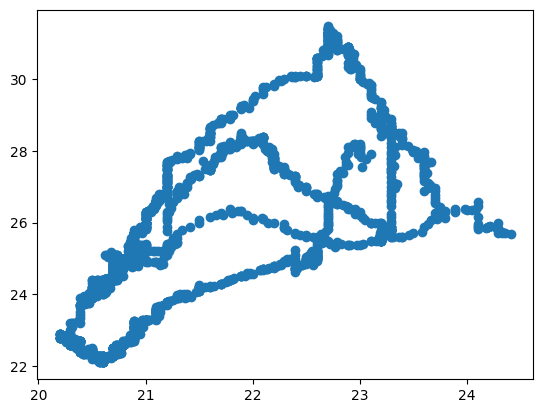

In [12]:
plt.scatter(X_test[:,0], X_test[:,1])

# Find best solution

In [13]:

best_solution_od = aaia.find_solution(
    X_train, 
    max_iterations=1000,
    population_size=50
)
print("best solution:", best_solution_od)

best solution: [2.14426471e+01 3.29928497e+01 1.50082204e+02 5.16415459e+02
 4.67719363e-03]


# Classify

In [14]:
labels, thresholds, distances_train, label_map = aaia.classify(X_train, y_train, X_test, best_solution_od)
n_clusters = len(np.unique(y_train))

print(f"Accuracy:  {accuracy_score(y_test, labels):.4f}")
print(f"Precision: {precision_score(y_test, labels, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, labels, average='macro'):.4f}")
print(f"F1:        {f1_score(y_test, labels, average='macro'):.4f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, labels))

Accuracy:  0.8240
Precision: 0.8849
Recall:    0.7605
F1:        0.7816

Confusion matrix:
[[1685    8]
 [ 461  511]]
